In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import sqrt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=3, suppress=True)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [5]:
n = 45
experience = np.linspace(0.5, 10, n)
noise = rng.normal(loc=0, scale=6500, size=n)
salary = 30000 + 8000 * experience + noise

df = pd.DataFrame({
    "experience_years": experience,
    "salary": salary
})

df.head()

,experience_years,salary
0,0.500000,35980.661018
1,0.715909,28967.376037
2,0.931818,42332.478227
3,1.147727,45295.488838
4,1.363636,28227.362183


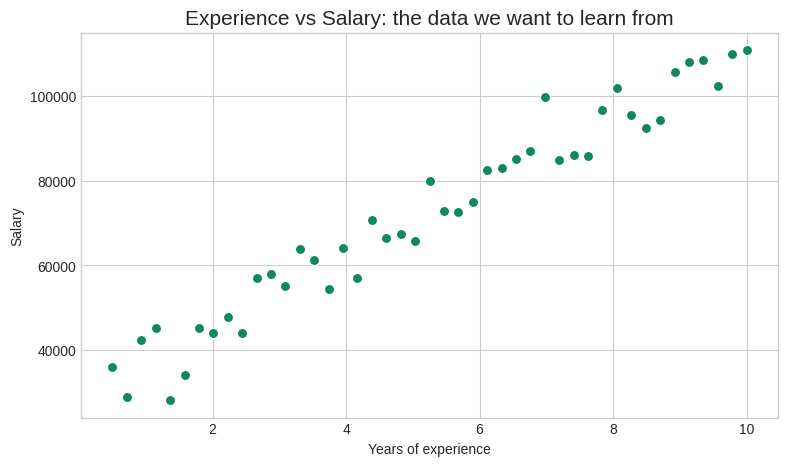

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df["experience_years"], df["salary"], s=55, color="#11875d", edgecolor="white")
ax.set_title("Experience vs Salary: the data we want to learn from", fontsize=15)
ax.set_xlabel("Years of experience")
ax.set_ylabel("Salary")
plt.show()

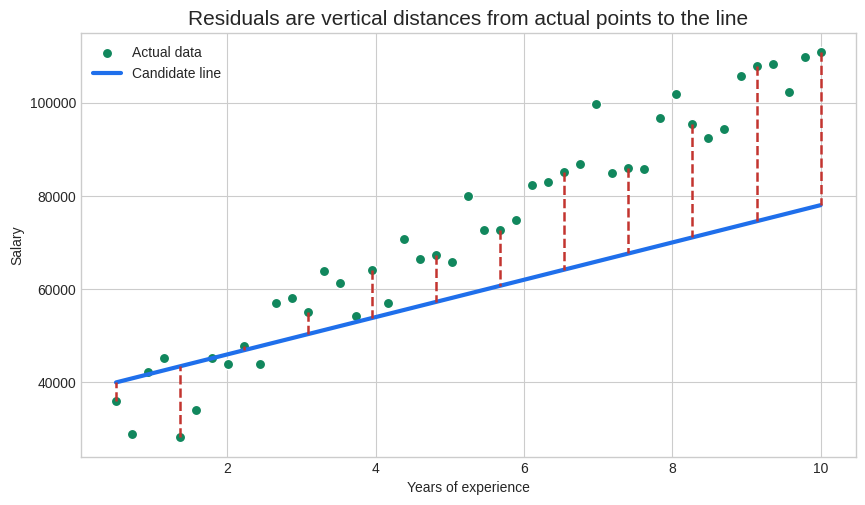

In [8]:
def plot_line_with_residuals(slope, intercept, title):
    x = df["experience_years"].to_numpy()
    y = df["salary"].to_numpy()
    y_pred = predict_line(x, slope, intercept)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.scatter(x, y, s=55, color="#11875d", edgecolor="white", label="Actual data")
    ax.plot(x, y_pred, color="#1f6feb", linewidth=3, label="Candidate line")

    # Draw residuals for a subset so the chart stays readable.
    subset = np.arange(0, len(x), 4)
    for i in subset:
        ax.plot([x[i], x[i]], [y[i], y_pred[i]], color="#c3342f", linestyle="--", linewidth=1.8)

    ax.set_title(title, fontsize=15)
    ax.set_xlabel("Years of experience")
    ax.set_ylabel("Salary")
    ax.legend()
    plt.show()

def predict_line(x, slope, intercept):
    return slope * x + intercept

plot_line_with_residuals(
    slope=4000,
    intercept=38000,
    title="Residuals are vertical distances from actual points to the line"
)


In [9]:
def regression_metrics(y_true, y_pred):
    n = len(y_true)
    errors = y_true - y_pred
    rss = ((errors) ** 2).sum()
    mse = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(errors))

    return {
        "rss": rss,
        "mse": mse,
        "rmse": rmse,
        "mae": mae
    }

In [18]:
x = df["experience_years"].to_numpy()
y = df["salary"].to_numpy()

candidate_models = [
    {"name": "Line A: too flat", "slope": 4000, "intercept": 48000},
    {"name": "Line B: better", "slope": 8224.170483411222, "intercept": 29184},
    {"name": "Line C: too steep", "slope": 11500, "intercept": 15000},
]

rows = []
for model in candidate_models:
    y_pred = predict_line(x, model["slope"], model["intercept"])
    metrics = regression_metrics(y, y_pred)
    rows.append({
        "model": model["name"],
        "slope": model["slope"],
        "intercept": model["intercept"],
        "MAE": metrics["mae"],
        "RMSE": metrics["rmse"],
        "MSE": metrics["mse"],
        "RSS": metrics["rss"]
    })

metrics_df = pd.DataFrame(rows)
metrics_df

,model,slope,intercept,MAE,RMSE,MSE,RSS
0,Line A: too flat,4000.000000,48000,10942.907644,13318.187553,1.773741e+08,7.981835e+09
1,Line B: better,8224.170483,29184,4193.068754,5077.194453,2.577790e+07,1.160006e+09
2,Line C: too steep,11500.000000,15000,9218.191865,10919.528946,1.192361e+08,5.365625e+09


) missing from font(s) Liberation Sans.
  plt.tight_layout()
) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


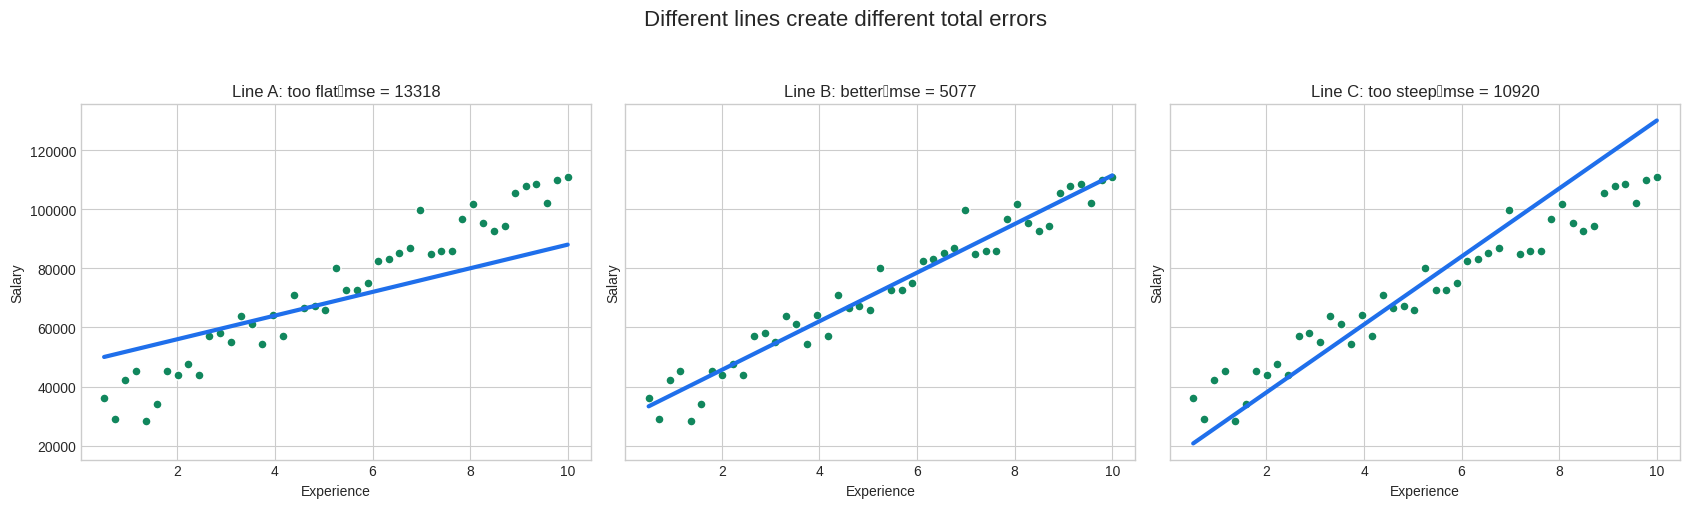

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)

for ax, model in zip(axes, candidate_models):
    y_pred = predict_line(x, model["slope"], model["intercept"])
    metrics = regression_metrics(y, y_pred)
    ax.scatter(x, y, s=42, color="#11875d", edgecolor="white")
    ax.plot(x, y_pred, color="#1f6feb", linewidth=3)
    ax.set_title(f"{model['name']}\rmse = {metrics['rmse']:.0f}", fontsize=12)
    ax.set_xlabel("Experience")
    ax.set_ylabel("Salary")

plt.suptitle("Different lines create different total errors", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [17]:
x_mean = np.mean(x)
y_mean = np.mean(y)

beta_1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
beta_0 = y_mean - beta_1 * x_mean

beta_1, beta_0

(np.float64(8224.170483411222), np.float64(29184.266046449906))

initialize betas with some random value

for each sample
    1. do forward pass - linear reg formula
    2. error calculation
    3. Compute the gradient
    4. update betas

In [23]:
x_scaled = (x - x_mean) / x.std() # scaled data has zero mean and unit standard deviation
y_k = y / 1000

def gradient_descent_simple(x_input, y_target, learning_rate=0.05, epochs=300):
    b0 = np.random.randn()
    b1 = np.random.randn()

    n = len(y_target)
    history = []

    for epoch in range(epochs+1):
        # forward pass
        y_hat = b0 + b1 * x_input
        error = (y_target - y_hat)
        mse = np.mean(error ** 2)

        history.append({
            "epoch": epoch,
            "b0": b0,
            "b1": b1,
            "mse": mse
        })

        # gradient calculation
        grad_b1 = -(1/n) * np.sum(error * x_input)
        grad_b0 = -(1/n) * np.sum(error)

        # weight update / backpropagation
        b0 = b0 - learning_rate * grad_b0
        b1 = b1 - learning_rate * grad_b1

    return pd.DataFrame(history)

In [36]:
gd_history = gradient_descent_simple(x_scaled, y_k, learning_rate=1.6)
gd_history.tail()

,epoch,b0,b1,mse
296,296,72.361161,23.060975,25.777903
297,297,72.361161,23.060975,25.777903
298,298,72.361161,23.060975,25.777903
299,299,72.361161,23.060975,25.777903
300,300,72.361161,23.060975,25.777903


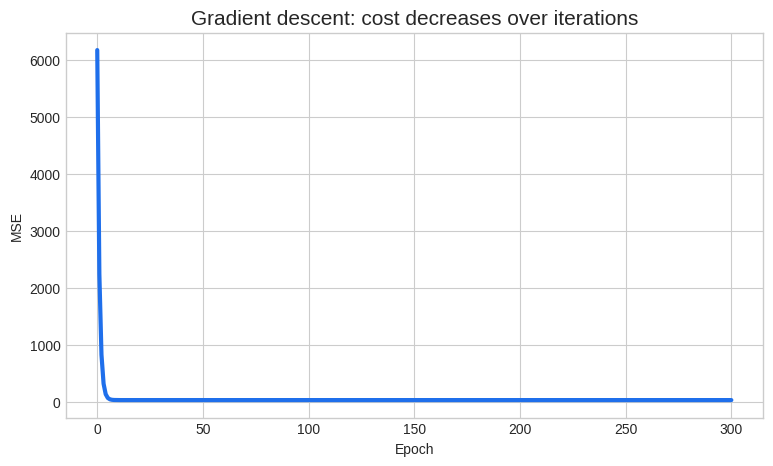

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gd_history["epoch"], gd_history["mse"], color="#1f6feb", linewidth=3)
ax.set_title("Gradient descent: cost decreases over iterations", fontsize=15)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
plt.show()

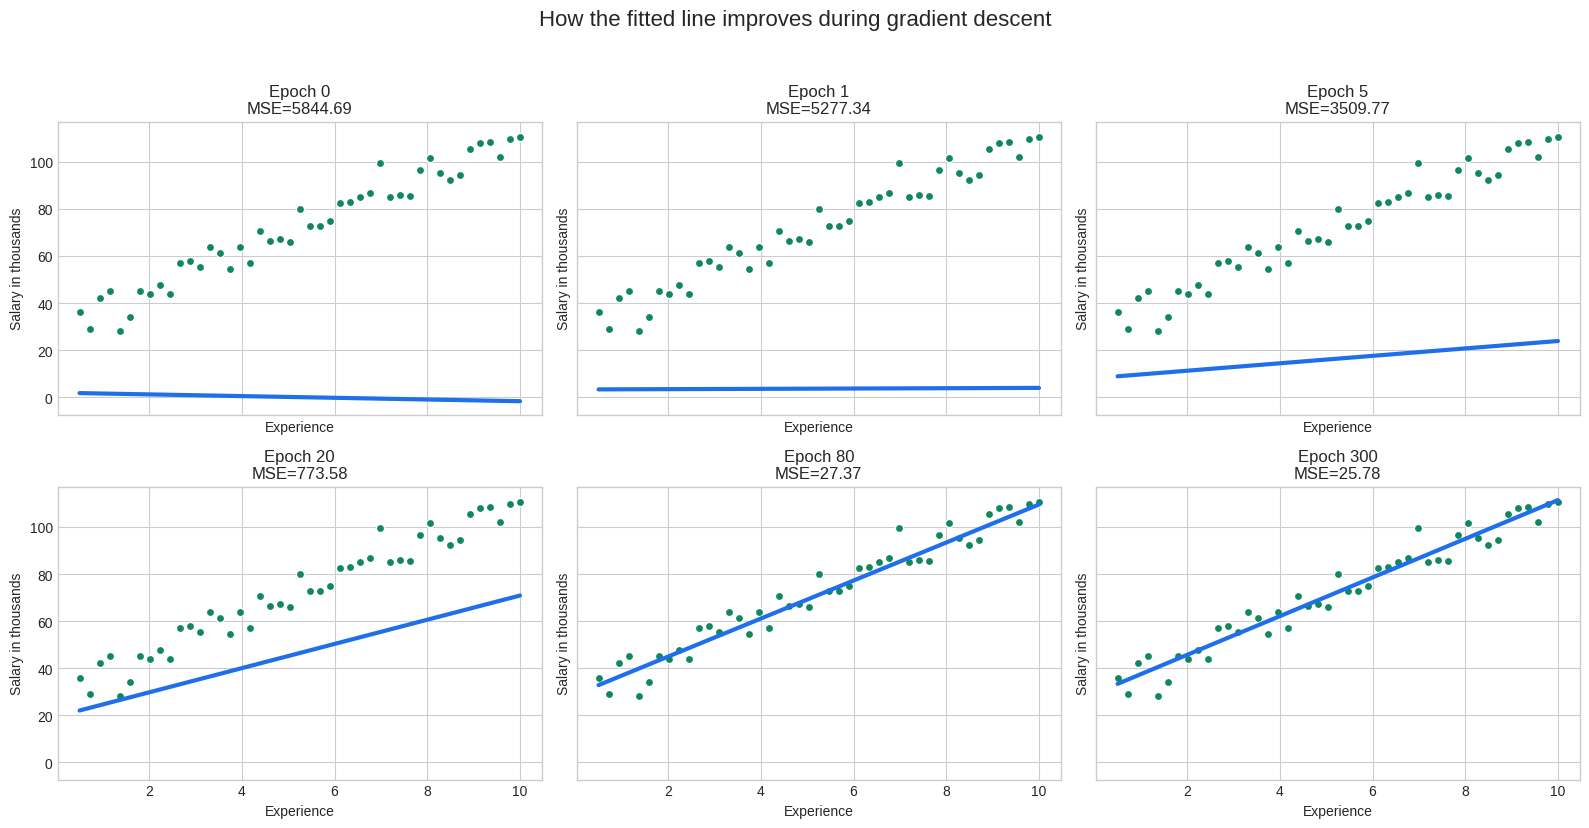

In [27]:
def plot_gd_lines_at_epochs(history, selected_epochs):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, epoch in zip(axes, selected_epochs):
        row = history.loc[history["epoch"] == epoch].iloc[0]
        pred_k = row["b0"] + row["b1"] * x_scaled

        ax.scatter(x, y_k, s=35, color="#11875d", edgecolor="white")
        ax.plot(x, pred_k, color="#1f6feb", linewidth=3)
        ax.set_title(f"Epoch {epoch}\nMSE={row['mse']:.2f}", fontsize=12)
        ax.set_xlabel("Experience")
        ax.set_ylabel("Salary in thousands")

    plt.suptitle("How the fitted line improves during gradient descent", fontsize=16, y=1.03)
    plt.tight_layout()
    plt.show()

plot_gd_lines_at_epochs(gd_history, selected_epochs=[0, 1, 5, 20, 80, 300])

In [38]:
try:
    from sklearn.linear_model import LinearRegression

    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)

    print("sklearn intercept:", model.intercept_)
    print("sklearn slope:", model.coef_[0])
    print("from-scratch intercept:", beta_0)
    print("from-scratch slope:", beta_1)
except ImportError:
    print("scikit-learn is not installed in this environment. The from-scratch OLS code above is enough for Session 1.")

sklearn intercept: 29184.266046449906
sklearn slope: 8224.170483411222
from-scratch intercept: 29184.266046449906
from-scratch slope: 8224.170483411222
